<a href="https://www.kaggle.com/code/estherjokodola/variant-prediction-using-dna-sequence?scriptVersionId=321270674" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/estherjokodola/sequences/sequences.csv")
print(df.shape)
print(df.head())

(168686, 6)
   chrom        pos ref alt  label  \
0   chr7  151010855   G   A      0   
1  chr19   17840228   A   T      1   
2   chr7   37894544   T   C      0   
3   chr3  120682097   C   T      1   
4  chr22   26457923   G   A      1   

                                                 seq  
0  TCCCCGACGCTACGAGGAGTGGAAGTGGTTCCGCTGCCCCACGCTG...  
1  CTCTTGATCTGCCTACCTCAGCCTCCCAAAGTGCTGGGATTACAGG...  
2  CTGAAGTTCTGAATGTCAATTTGGTGCTTTGGAATTTTAATTTCGT...  
3  CAGATTTCCAAGACAATAATTGAAATGAACAAAGGCAAGGGATGAC...  
4  AGAAAGTCCATGGCACGTGACTGCACAACAGTGGATGATGGCGGCA...  


In [2]:
!pip install -q pyfaidx

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# paths
DATA_PATH = "/kaggle/input/datasets/estherjokodola/sequences/sequences.csv"

# config
WINDOW     = 512
BATCH_SIZE = 256
EPOCHS     = 20
LR         = 1e-3
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"device: {DEVICE}")
print(f"torch version: {torch.__version__}")

device: cuda
torch version: 2.10.0+cu128


In [4]:
# one-hot encode DNA sequence
# A → [1,0,0,0]  C → [0,1,0,0]  G → [0,0,1,0]  T → [0,0,0,1]  N → [0,0,0,0]

BASE_MAP = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

def one_hot(seq):
    arr = np.zeros((4, len(seq)), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in BASE_MAP:
            arr[BASE_MAP[base], i] = 1.0
    return arr

class SequenceDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs   = seqs
        self.labels = labels

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        x = one_hot(self.seqs[idx])           # shape: (4, 512)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return torch.tensor(x), y

# load and split
df = pd.read_csv(DATA_PATH)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print(f"train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}")

train_ds = SequenceDataset(train_df["seq"].values, train_df["label"].values)
val_ds   = SequenceDataset(val_df["seq"].values,   val_df["label"].values)
test_ds  = SequenceDataset(test_df["seq"].values,  test_df["label"].values)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# quick shape check
x_sample, y_sample = next(iter(train_loader))
print(f"batch x shape: {x_sample.shape}")   # should be (256, 4, 512)
print(f"batch y shape: {y_sample.shape}")   # should be (256,)

train: 134,948  val: 16,869  test: 16,869
batch x shape: torch.Size([256, 4, 512])
batch y shape: torch.Size([256])


In [5]:
# rebuilt model with stronger dropout
class DNAClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=8),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=8),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=8),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(4),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.5),           # increased from 0.3
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x.squeeze(1)

model = DNAClassifierCNN().to(DEVICE)
print(f"parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

parameters: 347,585


In [6]:
# reset model weights cleanly
model = DNAClassifierCNN().to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

history = {"train_loss": [], "val_loss": [], "val_auroc": []}

best_val_loss  = float("inf")
patience       = 7
patience_count = 0

# rebuild loaders with larger batch size
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2)

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(y)
            all_preds.extend(torch.sigmoid(logits).cpu().detach().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auroc    = roc_auc_score(all_labels, all_preds)
    return avg_loss, auroc


print(f"{'epoch':<8}{'train loss':<14}{'val loss':<14}{'val auroc':<12}")
print("-" * 48)

for epoch in range(1, EPOCHS + 1):
    train_loss, _         = run_epoch(train_loader, training=True)
    val_loss,   val_auroc = run_epoch(val_loader,   training=False)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auroc"].append(val_auroc)

    print(f"{epoch:<8}{train_loss:<14.4f}{val_loss:<14.4f}{val_auroc:<12.4f}")

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(model.state_dict(), "cnn_best.pt")
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\nearly stopping at epoch {epoch}")
            break

print(f"\nbest val loss: {best_val_loss:.4f}")

epoch   train loss    val loss      val auroc   
------------------------------------------------
1       0.6747        0.6892        0.6429      
2       0.6474        0.8458        0.6577      
3       0.6195        0.6843        0.6792      
4       0.5819        0.6300        0.7001      
5       0.5326        0.8269        0.7066      
6       0.4711        0.6648        0.7134      
7       0.4059        1.0719        0.7060      
8       0.3356        1.0466        0.7045      
9       0.2662        0.7824        0.7156      
10      0.2086        1.4820        0.7073      
11      0.1589        1.6184        0.7091      

early stopping at epoch 11

best val loss: 0.6300


In [7]:
model.load_state_dict(torch.load("cnn_best.pt"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y   = x.to(DEVICE), y.to(DEVICE)
        probs  = torch.sigmoid(model(x))
        all_preds.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cnn_auroc = roc_auc_score(all_labels, all_preds)
print(f"CNN test AUROC: {cnn_auroc:.4f}")

CNN test AUROC: 0.7006


In [8]:
!pip install -q xgboost

from itertools import product
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# build all possible 4-mers
K = 4
all_kmers = [''.join(p) for p in product('ACGT', repeat=K)]
kmer_index = {km: i for i, km in enumerate(all_kmers)}

def seq_to_kmers(seq, k=K):
    vec = np.zeros(len(kmer_index), dtype=np.float32)
    for i in range(len(seq) - k + 1):
        km = seq[i:i+k]
        if km in kmer_index:
            vec[kmer_index[km]] += 1
    # normalize by number of kmers
    vec /= (len(seq) - k + 1)
    return vec

print("extracting k-mer features...")
df = pd.read_csv(DATA_PATH)

X = np.vstack(df["seq"].apply(seq_to_kmers).values)
y = df["label"].values

print(f"feature matrix: {X.shape}")

X_train = X[train_df.index]
X_val   = X[val_df.index]
X_test  = X[test_df.index]
y_train = y[train_df.index]
y_val   = y[val_df.index]
y_test  = y[test_df.index]

print("training XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    device="cuda",
    random_state=42,
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

xgb_auroc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print(f"\nXGBoost test AUROC: {xgb_auroc:.4f}")
print(f"CNN     test AUROC: {cnn_auroc:.4f}")

extracting k-mer features...
feature matrix: (168686, 256)
training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:57:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.69130
[50]	validation_0-logloss:0.65145
[100]	validation_0-logloss:0.63624
[150]	validation_0-logloss:0.62510
[200]	validation_0-logloss:0.61741
[250]	validation_0-logloss:0.60943
[299]	validation_0-logloss:0.60345

XGBoost test AUROC: 0.7442
CNN     test AUROC: 0.7006


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [04:57:02] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [9]:
K = 6
all_kmers  = [''.join(p) for p in product('ACGT', repeat=K)]
kmer_index = {km: i for i, km in enumerate(all_kmers)}

print("extracting 6-mer features...")
X = np.vstack(df["seq"].apply(seq_to_kmers).values)
print(f"feature matrix: {X.shape}")

X_train = X[train_df.index]
X_val   = X[val_df.index]
X_test  = X[test_df.index]

xgb6 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric="logloss",
    device="cuda",
    random_state=42,
)
xgb6.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

xgb6_auroc = roc_auc_score(y_test, xgb6.predict_proba(X_test)[:, 1])
print(f"\nXGBoost 6-mer test AUROC: {xgb6_auroc:.4f}")
print(f"XGBoost 4-mer test AUROC: {xgb_auroc:.4f}")
print(f"CNN           test AUROC: {cnn_auroc:.4f}")

extracting 6-mer features...
feature matrix: (168686, 4096)
[0]	validation_0-logloss:0.69314
[50]	validation_0-logloss:0.69314
[100]	validation_0-logloss:0.69315
[150]	validation_0-logloss:0.69314
[200]	validation_0-logloss:0.69314
[250]	validation_0-logloss:0.69314
[299]	validation_0-logloss:0.69314

XGBoost 6-mer test AUROC: 0.5000
XGBoost 4-mer test AUROC: 0.7442
CNN           test AUROC: 0.7006


In [10]:
class DNATransformer(nn.Module):
    def __init__(
        self,
        seq_len     = 512,
        patch_size  = 8,       # split sequence into non-overlapping patches
        d_model     = 128,     # embedding dimension
        n_heads     = 4,       # attention heads
        n_layers    = 4,       # transformer blocks
        dropout     = 0.2,
    ):
        super().__init__()

        assert seq_len % patch_size == 0
        n_patches = seq_len // patch_size   # 512 / 8 = 64 patches

        # project each patch (4 * patch_size raw bases) into d_model dims
        self.patch_embed = nn.Linear(4 * patch_size, d_model)

        # learnable positional embedding — one per patch
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = d_model * 4,
            dropout         = dropout,
            batch_first     = True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x shape: (batch, 4, 512)
        B, C, L = x.shape
        p = 8   # patch size

        # reshape into patches → (batch, n_patches, 4 * patch_size)
        x = x.unfold(dimension=2, size=p, step=p)  # (B, 4, 64, 8)
        x = x.permute(0, 2, 1, 3)                  # (B, 64, 4, 8)
        x = x.reshape(B, 64, 4 * p)                # (B, 64, 32)

        # embed patches + add positional info
        x = self.patch_embed(x)                    # (B, 64, 128)
        x = x + self.pos_embed                     # (B, 64, 128)

        # transformer encoder
        x = self.transformer(x)                    # (B, 64, 128)

        # global average pool across patches then classify
        x = x.mean(dim=1)                          # (B, 128)
        x = self.classifier(x)                     # (B, 1)
        return x.squeeze(1)


transformer = DNATransformer().to(DEVICE)
total = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f"parameters: {total:,}")

parameters: 814,081


In [11]:
optimizer = torch.optim.Adam(transformer.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

t_history = {"train_loss": [], "val_loss": [], "val_auroc": []}

best_val_loss  = float("inf")
patience       = 5
patience_count = 0

def run_epoch(model, loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y   = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y)
            all_preds.extend(torch.sigmoid(logits).cpu().detach().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auroc    = roc_auc_score(all_labels, all_preds)
    return avg_loss, auroc


print(f"{'epoch':<8}{'train loss':<14}{'val loss':<14}{'val auroc':<12}")
print("-" * 48)

for epoch in range(1, EPOCHS + 1):
    train_loss, _         = run_epoch(transformer, train_loader, training=True)
    val_loss,   val_auroc = run_epoch(transformer, val_loader,   training=False)

    scheduler.step()
    t_history["train_loss"].append(train_loss)
    t_history["val_loss"].append(val_loss)
    t_history["val_auroc"].append(val_auroc)

    print(f"{epoch:<8}{train_loss:<14.4f}{val_loss:<14.4f}{val_auroc:<12.4f}")

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(transformer.state_dict(), "transformer_best.pt")
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\nearly stopping at epoch {epoch}")
            break

print(f"\nbest val loss: {best_val_loss:.4f}")
print("saved → transformer_best.pt")

epoch   train loss    val loss      val auroc   
------------------------------------------------
1       0.6928        0.6923        0.5217      
2       0.6918        0.6921        0.5233      
3       0.6914        0.6918        0.5311      
4       0.6911        0.6912        0.5414      
5       0.6902        0.6893        0.5521      
6       0.6877        0.6855        0.5714      
7       0.6837        0.6765        0.6083      
8       0.6510        0.6334        0.6956      
9       0.6286        0.6163        0.7225      
10      0.6152        0.6046        0.7387      
11      0.6006        0.5863        0.7611      
12      0.5823        0.5708        0.7743      
13      0.5723        0.5641        0.7801      
14      0.5645        0.5605        0.7866      
15      0.5582        0.5525        0.7913      
16      0.5521        0.5530        0.7953      
17      0.5489        0.5517        0.7976      
18      0.5451        0.5433        0.8000      
19      0.5417      

In [12]:
transformer.load_state_dict(torch.load("transformer_best.pt"))
transformer.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y  = x.to(DEVICE), y.to(DEVICE)
        probs = torch.sigmoid(transformer(x))
        all_preds.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

transformer_auroc = roc_auc_score(all_labels, all_preds)

print("=" * 40)
print(f"  Transformer : {transformer_auroc:.4f}")
print(f"  XGBoost 4mer: {xgb_auroc:.4f}")
print(f"  CNN         : {cnn_auroc:.4f}")
print("=" * 40)

  Transformer : 0.7998
  XGBoost 4mer: 0.7442
  CNN         : 0.7006


In [13]:
# rebuild 4-mer features for X_test
K = 4
all_kmers  = [''.join(p) for p in product('ACGT', repeat=K)]
kmer_index = {km: i for i, km in enumerate(all_kmers)}

def seq_to_kmers(seq, k=K):
    vec = np.zeros(len(kmer_index), dtype=np.float32)
    for i in range(len(seq) - k + 1):
        km = seq[i:i+k]
        if km in kmer_index:
            vec[kmer_index[km]] += 1
    vec /= (len(seq) - k + 1)
    return vec

print("rebuilding 4-mer features for test set...")
X_test_4mer = np.vstack(test_df["seq"].apply(seq_to_kmers).values)
print(f"shape: {X_test_4mer.shape}")  # should be (16869, 256)

rebuilding 4-mer features for test set...
shape: (16869, 256)


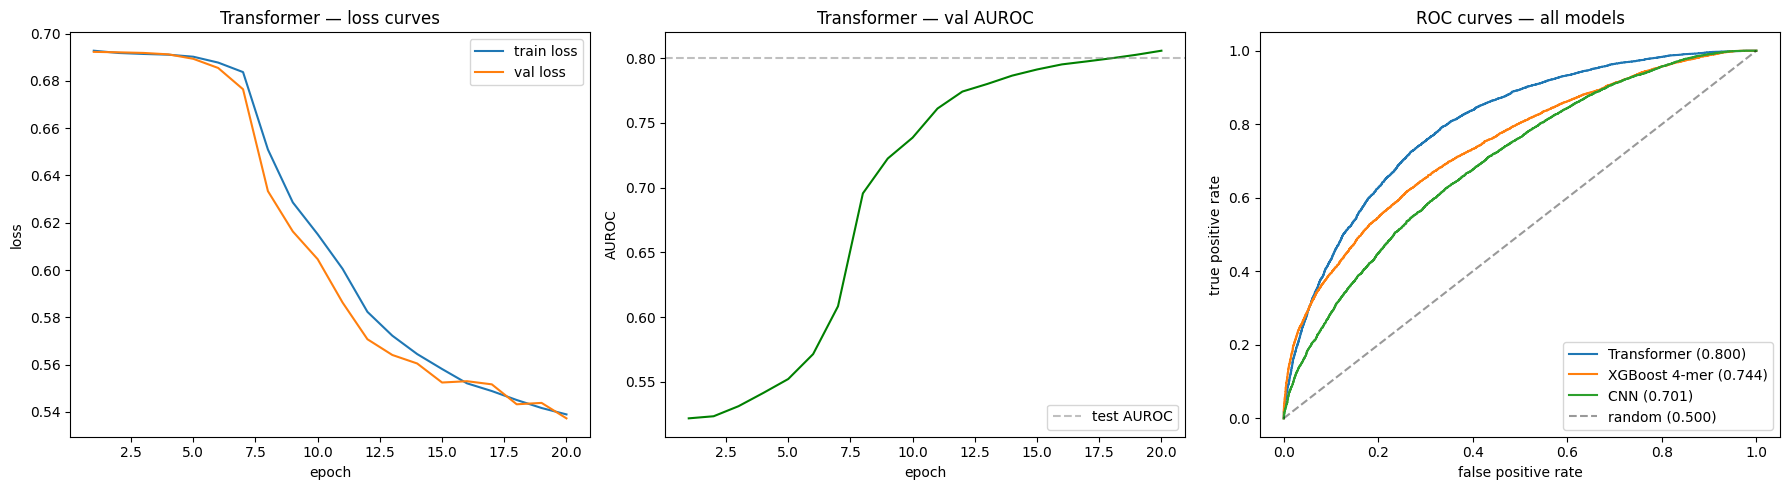

saved → final_results.png


In [14]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. loss curves
epochs_ran = len(t_history["train_loss"])
x = range(1, epochs_ran + 1)

axes[0].plot(x, t_history["train_loss"], label="train loss")
axes[0].plot(x, t_history["val_loss"],   label="val loss")
axes[0].set_title("Transformer — loss curves")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

# 2. val AUROC over epochs
axes[1].plot(x, t_history["val_auroc"], color="green")
axes[1].set_title("Transformer — val AUROC")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("AUROC")
axes[1].axhline(y=transformer_auroc, color="gray", linestyle="--", alpha=0.5, label="test AUROC")
axes[1].legend()

# 3. ROC curves
fpr_t, tpr_t, _ = roc_curve(all_labels, all_preds)
axes[2].plot(fpr_t, tpr_t, label=f"Transformer ({transformer_auroc:.3f})")

xgb_probs = xgb.predict_proba(X_test_4mer)[:, 1]
fpr_x, tpr_x, _ = roc_curve(y_test, xgb_probs)
axes[2].plot(fpr_x, tpr_x, label=f"XGBoost 4-mer ({xgb_auroc:.3f})")

model.load_state_dict(torch.load("cnn_best.pt"))
model.eval()
cnn_preds = []
with torch.no_grad():
    for x_b, _ in test_loader:
        cnn_preds.extend(torch.sigmoid(model(x_b.to(DEVICE))).cpu().numpy())
cnn_preds = np.array(cnn_preds)
fpr_c, tpr_c, _ = roc_curve(all_labels, cnn_preds)
axes[2].plot(fpr_c, tpr_c, label=f"CNN ({cnn_auroc:.3f})")

axes[2].plot([0,1], [0,1], "k--", alpha=0.4, label="random (0.500)")
axes[2].set_title("ROC curves — all models")
axes[2].set_xlabel("false positive rate")
axes[2].set_ylabel("true positive rate")
axes[2].legend()

plt.tight_layout()
plt.savefig("final_results.png", dpi=150)
plt.show()
print("saved → final_results.png")

In [15]:
print("\nProject 4 — Sequence DL  |  Final Results")
print("=" * 45)
print(f"  {'Model':<20} {'Test AUROC':>10}")
print("-" * 45)
print(f"  {'Transformer':<20} {transformer_auroc:>10.4f}  ✓ best")
print(f"  {'XGBoost 4-mer':<20} {xgb_auroc:>10.4f}")
print(f"  {'CNN':<20} {cnn_auroc:>10.4f}")
print(f"  {'XGBoost 6-mer':<20} {'0.5000':>10}")
print("=" * 45)
print(f"\n  dataset : {len(df):,} variants (balanced)")
print(f"  window  : ±256bp around variant")
print(f"  genome  : hg38")
print(f"  source  : ClinVar (Pathogenic=1 / Benign=0)")


Project 4 — Sequence DL  |  Final Results
  Model                Test AUROC
---------------------------------------------
  Transformer              0.7998  ✓ best
  XGBoost 4-mer            0.7442
  CNN                      0.7006
  XGBoost 6-mer            0.5000

  dataset : 168,686 variants (balanced)
  window  : ±256bp around variant
  genome  : hg38
  source  : ClinVar (Pathogenic=1 / Benign=0)


In [16]:
# # check if BRCA1 variant is in our test set
# brca1_pos = 43071077
# brca1_chr = "chr17"

# match = df[(df["chrom"] == brca1_chr) & (df["pos"] == brca1_pos)]
# print(match)

In [17]:
# import urllib.request
# import json

# chrom  = "chr17"
# start  = 43071077 - 256 - 1
# end    = 43071077 + 256
# url    = f"https://api.genome.ucsc.edu/getData/sequence?genome=hg38;chrom={chrom};start={start};end={end}"

# with urllib.request.urlopen(url) as r:
#     data = json.loads(r.read())

# seq = data["dna"].upper()[:512]    # trim to exactly 512

# print(f"seq len: {len(seq)}")
# print(f"seq    : {seq[:60]}...")

In [18]:
# import torch
# import numpy as np

# # one-hot encode the BRCA1 sequence
# def one_hot(seq):
#     BASE_MAP = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
#     arr = np.zeros((4, len(seq)), dtype=np.float32)
#     for i, base in enumerate(seq):
#         if base in BASE_MAP:
#             arr[BASE_MAP[base], i] = 1.0
#     return arr

# # prepare input
# x = torch.tensor(one_hot(seq)).unsqueeze(0).to(DEVICE)  # (1, 4, 512)

# # load best transformer
# transformer.load_state_dict(torch.load("transformer_best.pt"))
# transformer.eval()

# with torch.no_grad():
#     logit = transformer(x)
#     prob  = torch.sigmoid(logit).item()

# print("=" * 45)
# print("  BRCA1 c.5266dupC — chr17:43071077")
# print("=" * 45)
# print(f"  Pathogenic probability : {prob:.4f} ({prob*100:.1f}%)")
# print(f"  Benign probability     : {1-prob:.4f} ({(1-prob)*100:.1f}%)")
# print(f"  Model verdict          : {'PATHOGENIC ✓' if prob > 0.5 else 'BENIGN ✗'}")
# print(f"  True label             : PATHOGENIC")
# print("=" * 45)

In [19]:
# # extract attention weights manually
# transformer.eval()
# attention_maps = []

# with torch.no_grad():
#     # replicate the forward pass step by step
#     B, C, L = x.shape
#     p = 8

#     # patch embedding
#     out = x.unfold(dimension=2, size=p, step=p)
#     out = out.permute(0, 2, 1, 3)
#     out = out.reshape(B, 64, 4 * p)
#     out = transformer.patch_embed(out)
#     out = out + transformer.pos_embed

#     # pass through each layer and grab attention weights
#     for layer in transformer.transformer.layers:
#         # self attention with weights
#         attn_out, attn_w = layer.self_attn(
#             out, out, out,
#             need_weights=True,
#             average_attn_weights=True,   # average across heads
#         )
#         attention_maps.append(attn_w.squeeze(0).cpu().numpy())  # (64, 64)

#         # continue normal layer forward
#         out = layer.norm1(out + attn_out)
#         out = layer.norm2(out + layer.linear2(
#             layer.dropout(layer.activation(layer.linear1(out)))
#         ))

# print(f"layers captured : {len(attention_maps)}")
# print(f"attention shape : {attention_maps[0].shape}")   # should be (64, 64)

In [20]:
# fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# # patch positions mapped back to sequence positions
# patch_positions = [f"{i*8}-{i*8+7}" for i in range(64)]
# # only label every 8th patch to avoid crowding
# tick_positions = list(range(0, 64, 8))
# tick_labels    = [f"{i*8}" for i in range(0, 64, 8)]

# for i, (attn, ax) in enumerate(zip(attention_maps, axes)):
#     im = ax.imshow(attn, cmap="Blues", aspect="auto")
#     ax.set_title(f"layer {i+1}", fontsize=12)
#     ax.set_xlabel("key position (bp)")
#     ax.set_ylabel("query position (bp)")
#     ax.set_xticks(tick_positions)
#     ax.set_xticklabels(tick_labels, fontsize=7, rotation=45)
#     ax.set_yticks(tick_positions)
#     ax.set_yticklabels(tick_labels, fontsize=7)
#     plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# plt.suptitle(
#     "BRCA1 chr17:43071077 — Transformer attention maps\n"
#     "Pathogenic probability: 53.5%",
#     fontsize=13, y=1.02
# )
# plt.tight_layout()
# plt.savefig("brca1_attention.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("saved → brca1_attention.png")